In [13]:
import sys
import os
import torch
import torch.nn as nn
import pandas as pd

sys.path.append(os.path.abspath('..'))
import config
from src.model.architecture import TinyCNN

# Load the trained model
MODELS_DIR = os.path.join(config.OUTPUTS_DIR, 'models')
checkpoint = torch.load(os.path.join(MODELS_DIR, 'tinycnn_v3.pth'), map_location='cpu')

model = TinyCNN()
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Model loaded.')
print(f"  Checkpoint notes: {checkpoint['notes']}")
print(f"  Val accuracy:          {checkpoint['val_acc']:.4f}")
print(f"  Not_meaningful recall: {checkpoint['not_meaningful_recall']:.3f}")
print(f"  Not_meaningful F1:     {checkpoint['not_meaningful_f1']:.3f}")
print()

# Load labels and filter to unknown clips only
labels = pd.read_csv(config.LABELS_PROGRESS_PATH)
unknown = labels[labels['meaningful'] == 'unknown'].copy()

print(f'Total clips in catalog:  {len(labels):,}')
print(f'Unknown clips (to score): {len(unknown):,}')
print()
print('Recorders in unknown pool:')
print(unknown['Recorder'].value_counts())

Model loaded.
  Checkpoint notes: TinyCNN v3 — 11213 not_meaningful clips (acoustic scan + model_inference_v1 + model_inference_v2)
  Val accuracy:          0.9984
  Not_meaningful recall: 1.000
  Not_meaningful F1:     0.990

Total clips in catalog:  631,317
Unknown clips (to score): 501,164

Recorders in unknown pool:
Recorder
Audio_Moth_4    108466
Audio_Moth_5    101483
Audio_Moth_6     99387
Audio_Moth_2     84398
Audio_Moth_1     63203
Audio_Moth_3     44227
Name: count, dtype: int64


In [14]:
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

# Mel parameters — must match exactly what was used in training
SR         = 48000
DURATION   = 3.0
N_MELS     = 128
N_FFT      = 1024
HOP_LENGTH = 512
FMIN       = 50
FMAX       = 16000

def compute_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)
    expected = int(SR * DURATION)
    if len(y) < expected:
        y = np.pad(y, (0, expected - len(y)))
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(mel, ref=np.max)[:, :256].astype(np.float32)

class UnknownClipDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            mel = compute_mel(row["audio_path"])
        except Exception:
            mel = np.zeros((N_MELS, 256), dtype=np.float32)
        return torch.from_numpy(mel).unsqueeze(0), row["clip_name"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

loader = DataLoader(UnknownClipDataset(unknown), batch_size=64, shuffle=False, num_workers=0)

print(f"Scoring {len(unknown):,} unknown clips on {device}...")
print(f"Batches: {len(loader):,} × 64 clips")
print()

results = []
with torch.no_grad():
    for x, clip_names in tqdm(loader, total=len(loader)):
        x = x.to(device)
        probs = torch.sigmoid(model(x).squeeze(1)).cpu().numpy()
        for clip_name, prob in zip(clip_names, probs):
            results.append({"clip_name": clip_name, "not_meaningful_prob": float(1 - prob)})

results_df = pd.DataFrame(results)

out_path = os.path.join(config.OUTPUTS_DIR, "inference_v3.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved {len(results_df):,} predictions to {out_path}")

Scoring 501,164 unknown clips on mps...
Batches: 7,831 × 64 clips



  0%|          | 0/7831 [00:00<?, ?it/s]

/var/folders/b1/ntjf_3gn6zv2k1nf6cml66yw0000gn/T/ipykernel_60340/50795423.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)
/Users/qian/miniforge3/envs/ds/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Saved 501,164 predictions to /Users/qian/KWF/rainforest-audio-detection/outputs/inference_v3.csv


Total clips scored: 501,164

Score distribution (not_meaningful_prob):
       0.0-0.1:  490,766  (97.9%)
       0.1-0.3:    1,593  (0.3%)
       0.3-0.5:      847  (0.2%)
       0.5-0.7:      739  (0.1%)
       0.7-0.9:    1,061  (0.2%)
      0.9-0.95:      526  (0.1%)
     0.95-0.99:    1,161  (0.2%)
      0.99-1.0:    4,471  (0.9%)

High-confidence not_meaningful candidates:
  prob >= 0.90: 6,158 clips
  prob >= 0.95: 5,632 clips
  prob >= 0.99: 4,471 clips

Clips with not_meaningful_prob >= 0.95, by recorder:
Recorder
Audio_Moth_3    4440
Audio_Moth_6     444
Audio_Moth_2     289
Audio_Moth_1     207
Audio_Moth_5     132
Audio_Moth_4     120
Name: count, dtype: int64


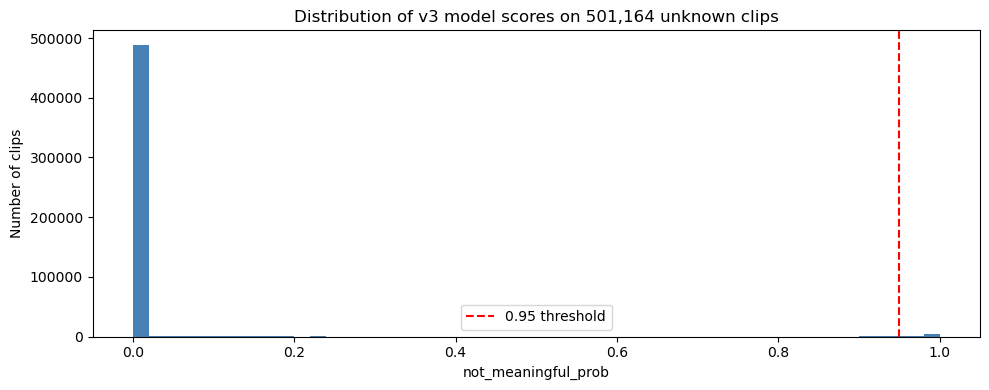

In [15]:
import matplotlib.pyplot as plt

# Load results and join recorder info
results_df = pd.read_csv(os.path.join(config.OUTPUTS_DIR, "inference_v3.csv"))
results_df = results_df.merge(unknown[["clip_name", "Recorder"]], on="clip_name", how="left")

print(f"Total clips scored: {len(results_df):,}")
print()

# Score distribution
print("Score distribution (not_meaningful_prob):")
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.01]
labels_b = ["0.0-0.1", "0.1-0.3", "0.3-0.5", "0.5-0.7", "0.7-0.9", "0.9-0.95", "0.95-0.99", "0.99-1.0"]
results_df["score_band"] = pd.cut(results_df["not_meaningful_prob"], bins=bins, labels=labels_b, right=False)
band_counts = results_df["score_band"].value_counts().sort_index()
for band, count in band_counts.items():
    pct = count / len(results_df) * 100
    print(f"  {band:>12}: {count:>8,}  ({pct:.1f}%)")

print()

# High-confidence thresholds
print("High-confidence not_meaningful candidates:")
for thresh in [0.90, 0.95, 0.99]:
    n = (results_df["not_meaningful_prob"] >= thresh).sum()
    print(f"  prob >= {thresh:.2f}: {n:,} clips")

print()

# By recorder — top not_meaningful candidates
print("Clips with not_meaningful_prob >= 0.95, by recorder:")
high_conf = results_df[results_df["not_meaningful_prob"] >= 0.95]
print(high_conf["Recorder"].value_counts())

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results_df["not_meaningful_prob"], bins=50, edgecolor="none", color="steelblue")
ax.set_xlabel("not_meaningful_prob")
ax.set_ylabel("Number of clips")
ax.set_title(f"Distribution of v3 model scores on {len(results_df):,} unknown clips")
ax.axvline(0.95, color="red", linestyle="--", label="0.95 threshold")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import shutil

AUDIT_DIR = os.path.join(config.OUTPUTS_DIR, "inference_audit_v3")
AUDIO_OUT = os.path.join(AUDIT_DIR, "audio")
AUDIT_CSV = os.path.join(AUDIT_DIR, "inference_audit_v3.csv")
os.makedirs(AUDIO_OUT, exist_ok=True)

SAMPLES_PER_RECORDER = 10
THRESHOLD = 0.95

candidates = results_df[results_df["not_meaningful_prob"] >= THRESHOLD].copy()
candidates = candidates.merge(unknown[["clip_name", "audio_path"]], on="clip_name", how="left")

print(f"High-confidence candidates (prob >= {THRESHOLD}): {len(candidates):,}")
print("By recorder:")
print(candidates["Recorder"].value_counts().sort_index())
print()

sample_df = (
    candidates
    .groupby("Recorder", group_keys=False)
    .apply(lambda g: g.sample(n=min(SAMPLES_PER_RECORDER, len(g)), random_state=42))
    .reset_index(drop=True)
)

print(f"Sampled for audit: {len(sample_df)} clips ({SAMPLES_PER_RECORDER} per recorder)")
print(sample_df["Recorder"].value_counts().sort_index())
print()

review_rows = []
missing = 0
for _, row in sample_df.iterrows():
    src = row["audio_path"]
    out_name = f"{row['Recorder']}_{row['clip_name']}"
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(AUDIO_OUT, out_name))
    else:
        missing += 1
        continue
    review_rows.append({
        "clip_name":           row["clip_name"],
        "recorder":            row["Recorder"],
        "not_meaningful_prob": round(row["not_meaningful_prob"], 4),
        "audio_file":          "audio/" + out_name,
        "category":            "",
        "notes":               "",
    })

review_df = pd.DataFrame(review_rows)
review_df = review_df.sort_values(["recorder", "not_meaningful_prob"], ascending=[True, False])
review_df.to_csv(AUDIT_CSV, index=False)

print(f"Audio copied to: {AUDIO_OUT}")
print(f"Review CSV:      {AUDIT_CSV}")
if missing:
    print(f"[WARN] {missing} audio files not found")

High-confidence candidates (prob >= 0.95): 5,632
By recorder:
Recorder
Audio_Moth_1     207
Audio_Moth_2     289
Audio_Moth_3    4440
Audio_Moth_4     120
Audio_Moth_5     132
Audio_Moth_6     444
Name: count, dtype: int64

Sampled for audit: 60 clips (10 per recorder)
Recorder
Audio_Moth_1    10
Audio_Moth_2    10
Audio_Moth_3    10
Audio_Moth_4    10
Audio_Moth_5    10
Audio_Moth_6    10
Name: count, dtype: int64

Audio copied to: /Users/qian/KWF/rainforest-audio-detection/outputs/inference_audit_v3/audio
Review CSV:      /Users/qian/KWF/rainforest-audio-detection/outputs/inference_audit_v3/inference_audit_v3.csv


/var/folders/b1/ntjf_3gn6zv2k1nf6cml66yw0000gn/T/ipykernel_60340/180456234.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(SAMPLES_PER_RECORDER, len(g)), random_state=42))


In [ ]:
from IPython.display import display, Audio, clear_output
import ipywidgets as widgets

adf = pd.read_csv(AUDIT_CSV)
adf["category"] = adf["category"].fillna("").astype(str)
adf["notes"]    = adf["notes"].fillna("").astype(str)

print(f"Total clips to review: {len(adf)}")
print(f"Already tagged: {(adf['category'] != '').sum()}")
print(f"Remaining:      {(adf['category'] == '').sum()}")

current_idx = [0]
CATEGORIES  = ["background", "meaningful", "unsure"]

category_dropdown = widgets.Dropdown(options=[""] + CATEGORIES, description="Category:", value="")
notes_text   = widgets.Text(description="Notes:", placeholder="optional")
prev_btn     = widgets.Button(description="◀ Prev")
next_btn     = widgets.Button(description="Next ▶", button_style="primary")
save_btn     = widgets.Button(description="💾 Save CSV", button_style="success")
jump_input   = widgets.IntText(value=0, description="Jump to:")
jump_btn     = widgets.Button(description="Go")
status_label = widgets.Label(value="")
output       = widgets.Output()

def show_clip(idx):
    with output:
        clear_output(wait=True)
        if idx < 0 or idx >= len(adf):
            print("Out of range.")
            return
        row = adf.iloc[idx]
        n_tagged = (adf["category"] != "").sum()
        print(f"Clip {idx+1} / {len(adf)}  |  Tagged: {n_tagged}/{len(adf)}")
        print(f"File:     {row['clip_name']}")
        print(f"Recorder: {row['recorder']}  |  not_meaningful_prob: {row['not_meaningful_prob']:.4f}")
        print(f"Current tag: '{row['category']}'  |  Notes: '{row['notes']}'")
        audio_path = os.path.join(AUDIT_DIR, row["audio_file"])
        if os.path.exists(audio_path):
            display(Audio(filename=audio_path))
        else:
            print(f"[Audio not found: {audio_path}]")
    category_dropdown.value = row["category"] if row["category"] in [""] + CATEGORIES else ""
    notes_text.value = row["notes"]

def save_current(auto=False):
    adf.at[current_idx[0], "category"] = category_dropdown.value
    adf.at[current_idx[0], "notes"]    = notes_text.value
    adf.to_csv(AUDIT_CSV, index=False)  # auto-save on every navigation
    n_tagged = (adf["category"] != "").sum()
    status_label.value = f"{'Auto-saved' if auto else '✓ Saved'}. {n_tagged}/{len(adf)} tagged."

def on_next(b):
    save_current(auto=True)
    if current_idx[0] < len(adf) - 1:
        current_idx[0] += 1
        show_clip(current_idx[0])
    else:
        status_label.value = "Reached the end. All progress saved."

def on_prev(b):
    save_current(auto=True)
    if current_idx[0] > 0:
        current_idx[0] -= 1
        show_clip(current_idx[0])

def on_save(b):
    save_current(auto=False)

def on_jump(b):
    save_current(auto=True)
    if 0 <= jump_input.value < len(adf):
        current_idx[0] = jump_input.value
        show_clip(current_idx[0])

next_btn.on_click(on_next)
prev_btn.on_click(on_prev)
save_btn.on_click(on_save)
jump_btn.on_click(on_jump)

display(widgets.VBox([
    output,
    category_dropdown, notes_text,
    widgets.HBox([prev_btn, next_btn, save_btn]),
    widgets.HBox([jump_input, jump_btn]),
    status_label,
]))
show_clip(0)


Total clips to review: 60
Already tagged: 0
Remaining:      60


In [19]:
# Reload to get saved tags
adf = pd.read_csv(AUDIT_CSV)
adf["category"] = adf["category"].fillna("").str.strip().str.lower()

print(f"Total reviewed: {len(adf)}")
print(f"Tagged:         {(adf['category'] != '').sum()}")
print()

print("Overall category distribution:")
print(adf["category"].value_counts())
print()

print("Category by recorder:")
print(pd.crosstab(adf["recorder"], adf["category"]))
print()

# Per-recorder precision — key quality gate before production labeling
# If any recorder is below ~85%, collect more negatives for that location
print("Precision (background rate) by recorder:")
for recorder in sorted(adf["recorder"].unique()):
    subset = adf[adf["recorder"] == recorder]
    total = len(subset)
    bg = (subset["category"] == "background").sum()
    flag = "  ← investigate" if total > 0 and bg / total < 0.85 else ""
    print(f"  {recorder}: {bg}/{total}  ({bg/total*100:.0f}%){flag}")

print()
overall_bg = (adf["category"] == "background").sum()
print(f"Overall: {overall_bg}/{len(adf)}  ({overall_bg/len(adf)*100:.0f}% precision)")

Total reviewed: 60
Tagged:         60

Overall category distribution:
category
background    57
meaningful     3
Name: count, dtype: int64

Category by recorder:
category      background  meaningful
recorder                            
Audio_Moth_1           9           1
Audio_Moth_2           9           1
Audio_Moth_3          10           0
Audio_Moth_4          10           0
Audio_Moth_5          10           0
Audio_Moth_6           9           1

Precision (background rate) by recorder:
  Audio_Moth_1: 9/10  (90%)
  Audio_Moth_2: 9/10  (90%)
  Audio_Moth_3: 10/10  (100%)
  Audio_Moth_4: 10/10  (100%)
  Audio_Moth_5: 10/10  (100%)
  Audio_Moth_6: 9/10  (90%)

Overall: 57/60  (95% precision)


In [ ]:
import shutil

AUDIT_DIR_AM12 = os.path.join(config.OUTPUTS_DIR, "inference_audit_v3_am12")
AUDIO_OUT_AM12 = os.path.join(AUDIT_DIR_AM12, "audio")
AUDIT_CSV_AM12 = os.path.join(AUDIT_DIR_AM12, "inference_audit_v3_am12.csv")
os.makedirs(AUDIO_OUT_AM12, exist_ok=True)

THRESHOLD_AM12 = 0.99

am12_candidates = results_df[
    (results_df["Recorder"].isin(["Audio_Moth_1", "Audio_Moth_2"])) &
    (results_df["not_meaningful_prob"] >= THRESHOLD_AM12)
].copy()
am12_candidates = am12_candidates.merge(unknown[["clip_name", "audio_path"]], on="clip_name", how="left")

print(f"AM1/AM2 candidates at prob >= {THRESHOLD_AM12}:")
print(am12_candidates["Recorder"].value_counts().sort_index())
print()

sample_df_am12 = (
    am12_candidates
    .groupby("Recorder", group_keys=False)
    .apply(lambda g: g.sample(n=min(10, len(g)), random_state=42))
    .reset_index(drop=True)
)

print(f"Sampled for audit: {len(sample_df_am12)} clips")
print(sample_df_am12["Recorder"].value_counts().sort_index())
print()

review_rows = []
missing = 0
for _, row in sample_df_am12.iterrows():
    src = row["audio_path"]
    out_name = f"{row['Recorder']}_{row['clip_name']}"
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(AUDIO_OUT_AM12, out_name))
    else:
        missing += 1
        continue
    review_rows.append({
        "clip_name":           row["clip_name"],
        "recorder":            row["Recorder"],
        "not_meaningful_prob": round(row["not_meaningful_prob"], 4),
        "audio_file":          "audio/" + out_name,
        "category":            "",
        "notes":               "",
    })

review_df_am12 = pd.DataFrame(review_rows)
review_df_am12 = review_df_am12.sort_values(["recorder", "not_meaningful_prob"], ascending=[True, False])
review_df_am12.to_csv(AUDIT_CSV_AM12, index=False)

print(f"Audio copied to: {AUDIO_OUT_AM12}")
print(f"Review CSV:      {AUDIT_CSV_AM12}")
if missing:
    print(f"[WARN] {missing} audio files not found")

In [ ]:
from IPython.display import display, Audio, clear_output
import ipywidgets as widgets

adf_am12 = pd.read_csv(AUDIT_CSV_AM12)
adf_am12["category"] = adf_am12["category"].fillna("").astype(str)
adf_am12["notes"]    = adf_am12["notes"].fillna("").astype(str)

print(f"Total clips to review: {len(adf_am12)}")
print(f"Already tagged: {(adf_am12['category'] != '').sum()}")
print(f"Remaining:      {(adf_am12['category'] == '').sum()}")

current_idx_am12 = [0]
CATEGORIES = ["background", "meaningful", "unsure"]

category_dropdown_am12 = widgets.Dropdown(options=[""] + CATEGORIES, description="Category:", value="")
notes_text_am12   = widgets.Text(description="Notes:", placeholder="optional")
prev_btn_am12     = widgets.Button(description="◀ Prev")
next_btn_am12     = widgets.Button(description="Next ▶", button_style="primary")
save_btn_am12     = widgets.Button(description="💾 Save CSV", button_style="success")
jump_input_am12   = widgets.IntText(value=0, description="Jump to:")
jump_btn_am12     = widgets.Button(description="Go")
status_label_am12 = widgets.Label(value="")
output_am12       = widgets.Output()

def show_clip_am12(idx):
    with output_am12:
        clear_output(wait=True)
        if idx < 0 or idx >= len(adf_am12):
            print("Out of range.")
            return
        row = adf_am12.iloc[idx]
        n_tagged = (adf_am12["category"] != "").sum()
        print(f"Clip {idx+1} / {len(adf_am12)}  |  Tagged: {n_tagged}/{len(adf_am12)}")
        print(f"File:     {row['clip_name']}")
        print(f"Recorder: {row['recorder']}  |  not_meaningful_prob: {row['not_meaningful_prob']:.4f}")
        print(f"Current tag: '{row['category']}'  |  Notes: '{row['notes']}'")
        audio_path = os.path.join(AUDIT_DIR_AM12, row["audio_file"])
        if os.path.exists(audio_path):
            display(Audio(filename=audio_path))
        else:
            print(f"[Audio not found: {audio_path}]")
    category_dropdown_am12.value = row["category"] if row["category"] in [""] + CATEGORIES else ""
    notes_text_am12.value = row["notes"]

def save_current_am12(auto=False):
    adf_am12.at[current_idx_am12[0], "category"] = category_dropdown_am12.value
    adf_am12.at[current_idx_am12[0], "notes"]    = notes_text_am12.value
    adf_am12.to_csv(AUDIT_CSV_AM12, index=False)
    n_tagged = (adf_am12["category"] != "").sum()
    status_label_am12.value = f"{'Auto-saved' if auto else '✓ Saved'}. {n_tagged}/{len(adf_am12)} tagged."

def on_next_am12(b):
    save_current_am12(auto=True)
    if current_idx_am12[0] < len(adf_am12) - 1:
        current_idx_am12[0] += 1
        show_clip_am12(current_idx_am12[0])
    else:
        status_label_am12.value = "Reached the end. All progress saved."

def on_prev_am12(b):
    save_current_am12(auto=True)
    if current_idx_am12[0] > 0:
        current_idx_am12[0] -= 1
        show_clip_am12(current_idx_am12[0])

def on_save_am12(b):
    save_current_am12(auto=False)

def on_jump_am12(b):
    save_current_am12(auto=True)
    if 0 <= jump_input_am12.value < len(adf_am12):
        current_idx_am12[0] = jump_input_am12.value
        show_clip_am12(current_idx_am12[0])

next_btn_am12.on_click(on_next_am12)
prev_btn_am12.on_click(on_prev_am12)
save_btn_am12.on_click(on_save_am12)
jump_btn_am12.on_click(on_jump_am12)

display(widgets.VBox([
    output_am12,
    category_dropdown_am12, notes_text_am12,
    widgets.HBox([prev_btn_am12, next_btn_am12, save_btn_am12]),
    widgets.HBox([jump_input_am12, jump_btn_am12]),
    status_label_am12,
]))
show_clip_am12(0)

Total clips to review: 20
Already tagged: 0
Remaining:      20


In [10]:
# Reload to get saved tags
adf_am12 = pd.read_csv(AUDIT_CSV_AM12)
adf_am12["category"] = adf_am12["category"].fillna("").str.strip().str.lower()

print(f"Total reviewed: {len(adf_am12)}")
print(f"Tagged:         {(adf_am12['category'] != '').sum()}")
print()

print("Category by recorder:")
print(pd.crosstab(adf_am12["recorder"], adf_am12["category"]))
print()

print("Precision at prob >= 0.99 (AM1/AM2 re-audit):")
for recorder in sorted(adf_am12["recorder"].unique()):
    subset = adf_am12[adf_am12["recorder"] == recorder]
    total = len(subset)
    bg = (subset["category"] == "background").sum()
    flag = "  ← still below threshold, skip auto-labeling" if total > 0 and bg / total < 0.85 else "  ✓ passed"
    print(f"  {recorder}: {bg}/{total}  ({bg/total*100:.0f}%){flag}")

print()
print("Decision: recorders that passed → label at prob >= 0.99")
print("          recorders that failed → skip auto-labeling this iteration")

Total reviewed: 20
Tagged:         20

Category by recorder:
category      background  meaningful
recorder                            
Audio_Moth_1           9           1
Audio_Moth_2           9           1

Precision at prob >= 0.99 (AM1/AM2 re-audit):
  Audio_Moth_1: 9/10  (90%)  ✓ passed
  Audio_Moth_2: 9/10  (90%)  ✓ passed

Decision: recorders that passed → label at prob >= 0.99
          recorders that failed → skip auto-labeling this iteration


In [ ]:
# Fix: revert AM1/AM2 clips that were labeled at prob >= 0.95 but should require prob >= 0.99
# Run this only if the labeling cell was accidentally run before the AM1/AM2 re-audit.

labels = pd.read_csv(config.LABELS_PROGRESS_PATH)
scores = pd.read_csv(os.path.join(config.OUTPUTS_DIR, "inference_v3.csv"))
scores = scores.merge(labels[["clip_name", "Recorder"]], on="clip_name", how="left")

# Find AM1/AM2 clips labeled by model_inference_v3 with prob between 0.95 and 0.99
to_revert_mask = (
    (labels["meaningful_source"] == "model_inference_v3") &
    (labels["Recorder"].isin(["Audio_Moth_1", "Audio_Moth_2"]))
)
to_revert_clips = labels[to_revert_mask]["clip_name"].tolist()

scores_am12 = scores[scores["clip_name"].isin(to_revert_clips)]
below_99 = scores_am12[scores_am12["not_meaningful_prob"] < 0.99]["clip_name"].tolist()

print(f"AM1/AM2 clips labeled by model_inference_v3:  {len(to_revert_clips)}")
print(f"  prob >= 0.99 (keep):                        {len(to_revert_clips) - len(below_99)}")
print(f"  prob 0.95–0.99 (revert to unknown):         {len(below_99)}")
print()

revert_mask = labels["clip_name"].isin(below_99)
labels.loc[revert_mask, "meaningful"]        = "unknown"
labels.loc[revert_mask, "meaningful_source"] = "unlabeled"

print("Updated label state:")
print(labels["meaningful"].value_counts())
print()
print(labels["meaningful_source"].value_counts())

labels.to_csv(config.LABELS_PROGRESS_PATH, index=False)
print(f"\nSaved to: {config.LABELS_PROGRESS_PATH}")

In [20]:
# Label high-confidence not_meaningful clips in labels_progress.csv
# v3 audit: all 6 recorders passed at prob >= 0.95 — uniform threshold for all

labels = pd.read_csv(config.LABELS_PROGRESS_PATH)

results_full = pd.read_csv(os.path.join(config.OUTPUTS_DIR, "inference_v3.csv"))
results_full = results_full.merge(
    labels[["clip_name", "Recorder", "meaningful"]],
    on="clip_name", how="left"
)

candidates_mask = (
    (results_full["not_meaningful_prob"] >= 0.95) &
    (results_full["meaningful"] == "unknown")
)

candidates = results_full[candidates_mask]["clip_name"].tolist()
print(f"Candidates to label: {len(candidates):,}")
print()
print("By recorder:")
print(results_full[candidates_mask]["Recorder"].value_counts().sort_index())
print()

update_mask = labels["clip_name"].isin(candidates) & (labels["meaningful"] == "unknown")
labels.loc[update_mask, "meaningful"]        = "not_meaningful"
labels.loc[update_mask, "meaningful_source"] = "model_inference_v3"

print("Updated label state:")
print(labels["meaningful"].value_counts())
print()
print(labels["meaningful_source"].value_counts())

labels.to_csv(config.LABELS_PROGRESS_PATH, index=False)
print(f"\nSaved to: {config.LABELS_PROGRESS_PATH}")

Candidates to label: 5,632

By recorder:
Recorder
Audio_Moth_1     207
Audio_Moth_2     289
Audio_Moth_3    4440
Audio_Moth_4     120
Audio_Moth_5     132
Audio_Moth_6     444
Name: count, dtype: int64

Updated label state:
meaningful
unknown           495532
meaningful        118940
not_meaningful     16845
Name: count, dtype: int64

meaningful_source
unlabeled              495532
birdnet_species        108069
human_activity          10871
model_inference_v3       5632
model_inference_v2       4716
model_inference_v1       3500
background_flatness      2903
background_energy          94
Name: count, dtype: int64

Saved to: /Users/qian/KWF/rainforest-audio-detection/outputs/labels_progress.csv
